In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 14.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 MB 6.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 18.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.7/244.7 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 20.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-toolkit
    Found existing installation: cuda-toolkit 12.8.1
    Uninstalling cuda-toolkit-12.8.1:
      Successfully uninstalled cuda-toolkit-12.8.1
ERROR: pip's depende

In [8]:
!git clone https://github.com/Ankit-539/QuanSToS.git

Cloning into 'QuanSToS'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 94 (delta 54), reused 39 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 49.96 KiB | 7.14 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [9]:
%cd QuanSToS

/content/QuanSToS


In [1]:
from time import perf_counter

# import cupy as cp
import numpy as np
import array_api_compat
import array_api_compat.cupy as cp
import matplotlib.pyplot as plt

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    inverse_estimator,
    mle,
    fidelity,
    negativity,
    pauli_measurement,
    plot_counts
)

# Virtual Pauli measurements

XXX  [12482 12541 12480 12593 12491 12593 12401 12419]
XXY  [12506 12429 12572 12565 12514 12488 12456 12470]
XXZ  [21280  3724 21174  3668 21420  3644 21358  3732]
XYX  [12487 12540 12586 12603 12580 12474 12405 12325]
XYY  [12420 12540 12580 12466 12521 12518 12414 12541]
XYZ  [21044  3825 21285  3741 21378  3793 21189  3745]
XZX  [20987 21335  3716  3775 21268 21318  3787  3814]
XZY  [21177 21277  3692  3751 21421 21251  3712  3719]
XZZ  [38598  3705  3652  3796 39113  3719  3692  3725]
YXX  [12429 12450 12500 12321 12487 12619 12492 12702]
YXY  [12551 12728 12400 12582 12454 12256 12592 12437]
YXZ  [21202  3758 21077  3716 21280  3893 21240  3834]
YYX  [12571 12521 12493 12378 12472 12524 12681 12360]
YYY  [12545 12574 12479 12605 12603 12552 12362 12280]
YYZ  [21196  3606 21183  3769 21382  3732 21466  3666]
YZX  [21248 21128  3702  3798 21367 21296  3710  3751]
YZY  [21260 21325  3754  3802 21159 21197  3725  3778]
YZZ  [38540  3723  3838  3698 38871  3687  3801  3842]
ZXX  [2107

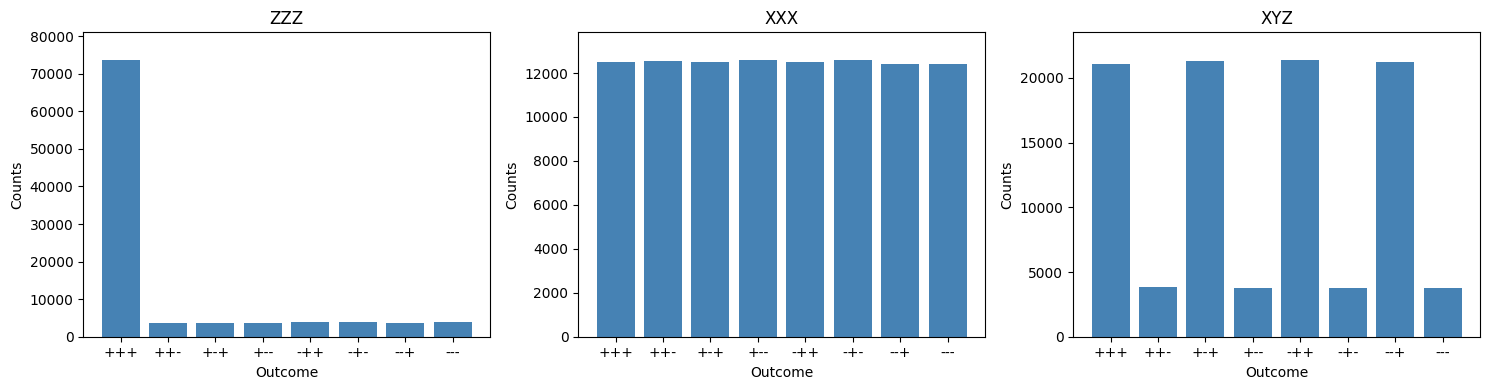

In [ ]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = (p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12458 12707 12491 12475 12445 12338 12650 12436]
XXY  [12569 12382 12529 12467 12541 12537 12472 12503]
XXZ  [25076     0 24837     0 25163     0 24924     0]
XYX  [12350 12612 12440 12580 12589 12299 12568 12562]
XYY  [12592 12678 12357 12347 12630 12541 12444 12411]
XYZ  [24854     0 25069     0 25108     0 24969     0]
XZX  [24989 25150     0     0 24963 24898     0     0]
XZY  [24991 24938     0     0 25082 24989     0     0]
XZZ  [50002     0     0     0 49998     0     0     0]
YXX  [12523 12448 12620 12360 12547 12595 12451 12456]
YXY  [12455 12356 12592 12587 12573 12578 12546 12313]
YXZ  [24636     0 25217     0 25111     0 25036     0]
YYX  [12547 12416 12576 12574 12418 12484 12516 12469]
YYY  [12602 12574 12460 12282 12606 12546 12428 12502]
YYZ  [25204     0 25058     0 24914     0 24824     0]
YZX  [25192 24826     0     0 24960 25022     0     0]
YZY  [25098 25162     0     0 24976 24764     0     0]
YZZ  [49760     0     0     0 50240     0     0     0]
ZXX  [2507

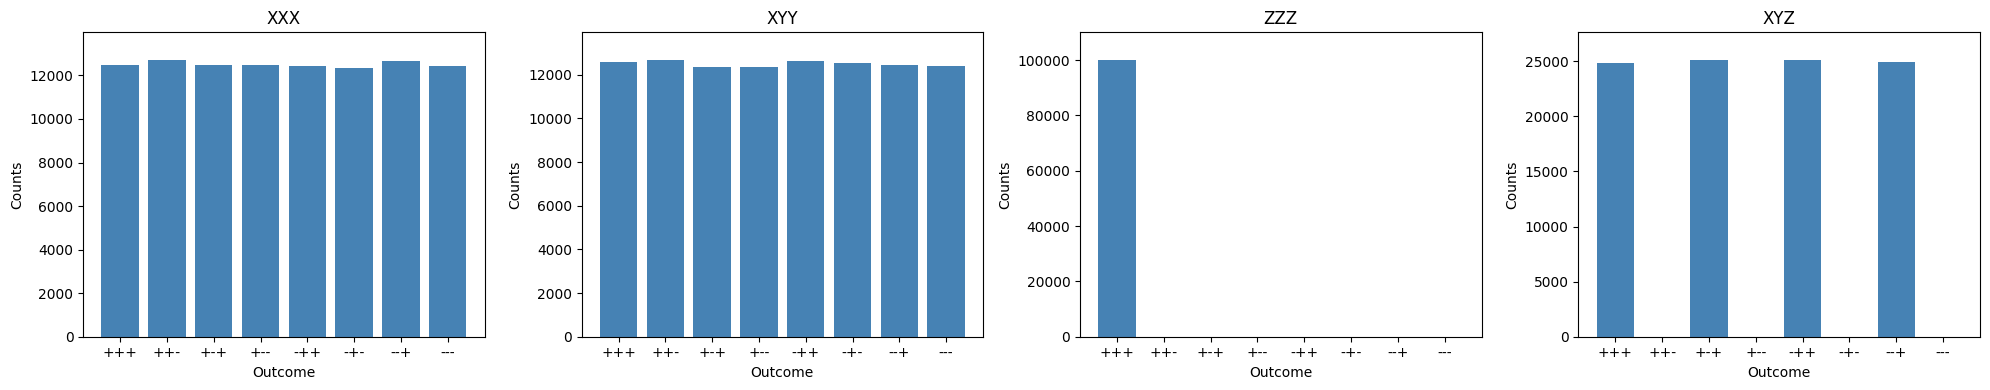

In [12]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

In [ ]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


# Hardware Benchmarking

### CPU (NumPy)

### GPU (CuPy)

# Noise Resilience

### Data generation

In [53]:
n = 4
Ns = list(2**i for i in range(3, 20))

# xp = cp
xp = np

haar_rho = get_random_haar(n, xp)
# X = xp.asarray([
#     [0, 1],
#     [1, 0]
# ], dtype=xp.complex128)
# haar_rho = (xp.identity(2**n) + xp.kron(X, X)) / 2**n
prod_rho = get_random_product(n, xp)

haar_countss = []
prod_countss = []
for N in Ns:
    haar_counts = pauli_measurement(haar_rho, N).counts
    prod_counts = pauli_measurement(prod_rho, N).counts
    haar_countss.append(haar_counts)
    prod_countss.append(prod_counts)

### Estimation

In [54]:
haar_fs = []
prod_fs = []
haar_ns = []
prod_ns = []
for i, N in enumerate(Ns):
    haar_counts = haar_countss[i]
    prod_counts = prod_countss[i]

    haar_est = inverse_estimator(haar_counts)
    prod_est = inverse_estimator(prod_counts)

    haar_f = float(xp.linalg.norm(haar_rho - haar_est))
    prod_f = float(xp.linalg.norm(prod_rho - prod_est))
    # haar_f = fidelity(haar_rho, haar_est)
    # prod_f = fidelity(prod_rho, prod_est)
    haar_fs.append(haar_f)
    prod_fs.append(prod_f)

    haar_n = float(negativity(haar_est))
    prod_n = float(negativity(prod_est))
    haar_ns.append(haar_n)
    prod_ns.append(prod_n)

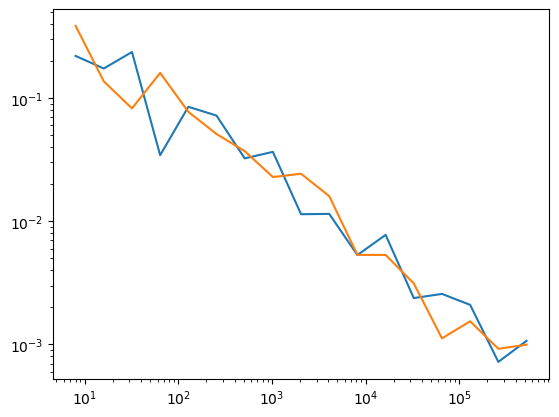

In [40]:
plt.plot(Ns, haar_ns)
plt.plot(Ns, prod_ns)

plt.xscale('log')
plt.yscale('log')

# Advanced Protocols (Classical Shadows)